In [1]:
pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [2]:
#libraries
import spacy
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import pipeline
from collections import defaultdict

**Load a Dickens Text**

In [3]:
# nicholas nickleby
url = "https://www.gutenberg.org/cache/epub/967/pg967.txt"
text = requests.get(url).text

**Preprocess & Load into spaCy**

In [4]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 9000000000000000000

doc = nlp(text[3000:])

**Extract Sentences with Mental State Verbs**

In [5]:
theory_of_mind_verbs = [
    "think", "believe", "know", "wonder", "suppose", "realize",
    "realise","imagine", "guess", "doubt", "feel", "consider",
    "hope","wish", "suspect", "predict", "expect", "assume", "fear"
]

matching_sentences = []

for sent in doc.sents:
    if any(token.lemma_ in theory_of_mind_verbs for token in sent):
        matching_sentences.append(sent.text)

**Count Mental State Verb Frequency**

In [6]:
verb_counts = Counter()

for sent in doc.sents:
    for token in sent:
        if token.lemma_ in theory_of_mind_verbs:
            verb_counts[token.lemma_] += 1

print(verb_counts.most_common())

[('know', 997), ('think', 745), ('hope', 197), ('feel', 190), ('suppose', 185), ('wish', 156), ('believe', 116), ('consider', 104), ('expect', 95), ('doubt', 94), ('fear', 86), ('wonder', 72), ('assume', 31), ('suspect', 22), ('imagine', 19), ('guess', 17), ('realise', 8), ('predict', 1)]


**Visualise Frequency Over Time (Chunk-Based)**

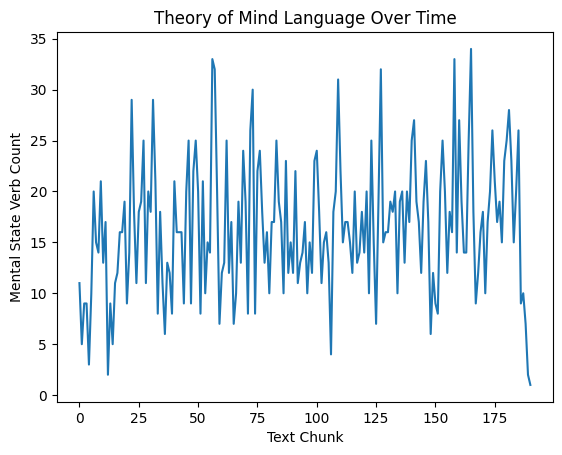

In [7]:
chunk_size = 10000  # adjustments can be made
chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
counts_over_time = []

for chunk in chunks:
    doc = nlp(chunk)
    count = sum(1 for token in doc if token.lemma_ in theory_of_mind_verbs)
    counts_over_time.append(count)

plt.plot(counts_over_time)
plt.xlabel("Text Chunk")
plt.ylabel("Mental State Verb Count")
plt.title("Theory of Mind Language Over Time")
plt.show()

**Track Character Co-occurrence**
To find which characters are associated with mental states.

In [8]:
characters = [
    "Nicholas Nickleby", "Nicholas", "Nickleby", "Mr. Nickleby",
    "Kate Nickleby", "Kate", "Miss Nickleby",
    "Mrs. Nickleby", "Nicholas's mother",
    "Ralph Nickleby", "Ralph", "Mr. Ralph Nickleby", "Uncle Ralph",
    "Smike", "Smith", "Mr. Smike", "the poor boy",
    "Newman Noggs", "Mr. Noggs", "Noggs",
    "Wackford Squeers", "Mr. Squeers", "Squeers",
    "Mrs. Squeers",
    "Fanny Squeers", "Miss Squeers",
    "Young Wackford", "Master Wackford Squeers",
    "Madeline Bray", "Madeline", "Miss Bray",
    "Walter Bray", "Mr. Bray", "Madeline's father",
    "Sir Mulberry Hawk", "Sir Mulberry",
    "Lord Frederick Verisopht", "Lord Frederick",
    "Frank Cheeryble", "Frank", "Mr. Frank Cheeryble",
    "Charles Cheeryble", "Mr. Charles", "Mr. Cheeryble",
    "Ned Cheeryble", "Ned", "Mr. Ned Cheeryble",
    "John Browdie", "Mr. Browdie",
    "Matilda Price", "Tilda", "Mrs. Browdie",
    "Miss La Creevy", "La Creevy",
    "Mr. Lillyvick", "Lillyvick",
    "Henrietta Petowker", "Miss Petowker",
    "Mr. Crummles", "Vincent Crummles",
    "Mrs. Crummles",
    "The Infant Phenomenon",
    "Mr. Folair",
    "Mr. Lenville",
    "Mrs. Lenville",
    "Mr. Snittle Timberry",
    "Mr. Mantalini", "Alfred Mantalini",
    "Madame Mantalini", "Miss Knag",
    "Miss Knag",
    "Mr. Mantelini",
    "Tom Linkinwater", "Mr. Linkinwater",
    "Bray",
    "Mr. Gride", "Arthur Gride",
    "Mr. Squeers Junior",  # Young Wackford again
    "Peg Sliderskew", "Mrs. Sliderskew",
    "The Kenwigses", "Mr. Kenwig", "Mrs. Kenwig",
    "Miss Morleena Kenwig", "Morleena",
    "Mr. Snawley",
    "Mr. Pyke", "Pyke",
    "Mr. Pluck", "Pluck",
    "Miss Ledrook",
    "Timothy Linkinwater",
    "The Misses Cheeryble",
    "Theatrical Manager",  # unnamed
    "Schoolmaster",  # used generically for Squeers
    "The Infant",  # alternate mention of Infant Phenomenon
]


character_mentalization = {name: 0 for name in characters}

for sent in matching_sentences:
    for name in characters:
        if name in sent:
            character_mentalization[name] += 1

print(character_mentalization)

{'Amy Dorrit': 0, 'Little Dorrit': 0, 'Amy': 0, 'Miss Dorrit': 0, 'William Dorrit': 0, 'Father of the Marshalsea': 0, 'Mr. Dorrit': 0, 'William': 0, 'Edward Dorrit': 0, 'Tip': 0, 'Mr. Edward Dorrit': 0, 'Fanny Dorrit': 0, 'Miss Fanny Dorrit': 0, 'Fanny': 6, 'Arthur Clennam': 0, 'Mr. Clennam': 0, 'Arthur': 21, 'Mrs. Clennam': 0, 'Mother Clennam': 0, 'Mrs. C.': 0, 'Flora Finching': 0, 'Mrs. Finching': 0, 'Flora Casby': 0, 'Mr. Casby': 0, 'Christopher Casby': 0, 'The Patriarch': 0, 'Pancks': 0, 'Mr. Pancks': 0, 'Mr. Meagles': 0, 'Mrs. Meagles': 0, 'Pet Meagles': 0, 'Tattycoram': 0, 'Harriet Beadle': 0, 'Pet': 12, 'Mr. Doyce': 0, 'Daniel Doyce': 0, 'Mr. Merdle': 0, 'Merdle': 0, 'The Great Financier': 0, 'Mrs. Merdle': 0, "Mr. Sparkler's Ma": 0, 'Edmund Sparkler': 0, 'Mr. Sparkler': 0, 'Rigaud': 0, 'Blandois': 0, 'Monsieur Rigaud': 0, 'Lagnier': 0, 'Cavalletto': 0, 'John Baptist Cavalletto': 0, 'Affery Flintwinch': 0, 'Mrs. Flintwinch': 0, 'Affery': 0, 'Jeremiah Flintwinch': 0, 'Mr. Flintwi



---



**BERT-Based Emotion Detection**

**Load Pretrained Emotion Model**

In [9]:
# load emotion classifier pipeline
emotion_pipeline = pipeline("text-classification",
                            model="j-hartmann/emotion-english-distilroberta-base",
                            return_all_scores=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


**Run Emotion Detection on the Whole Book**

In [10]:
def chunk_text(text, size=1000):
    words = text.split()
    return [' '.join(words[i:i+size]) for i in range(0, len(words), size)]

chunks = chunk_text(text[3000:], size=20000)

emotion_scores = []

for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        scores_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(scores_dict)
    except:
        continue

**Convert to DataFrame & Plot Emotion Arcs**

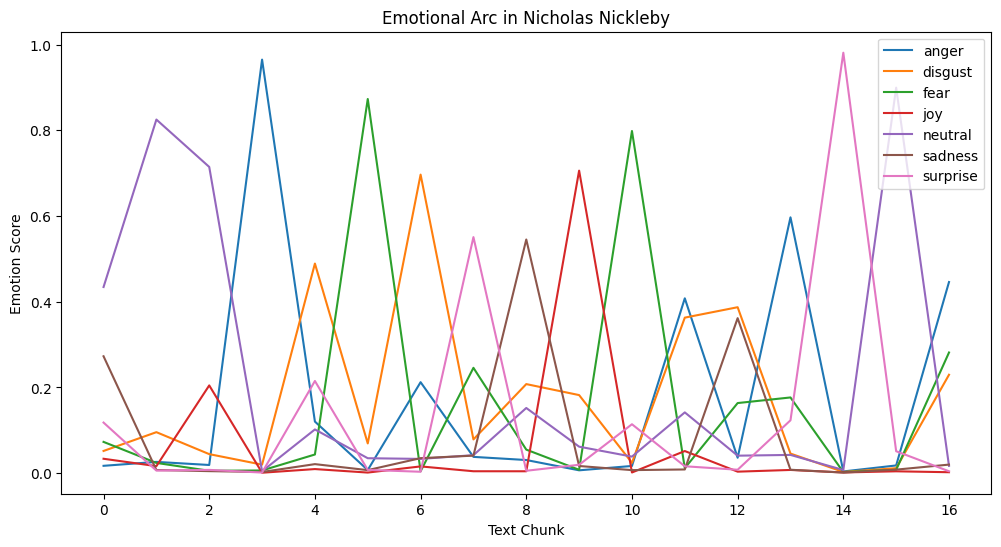

In [11]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)

plt.legend()
plt.title("Emotional Arc in Nicholas Nickleby")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.show()

Total Emotions

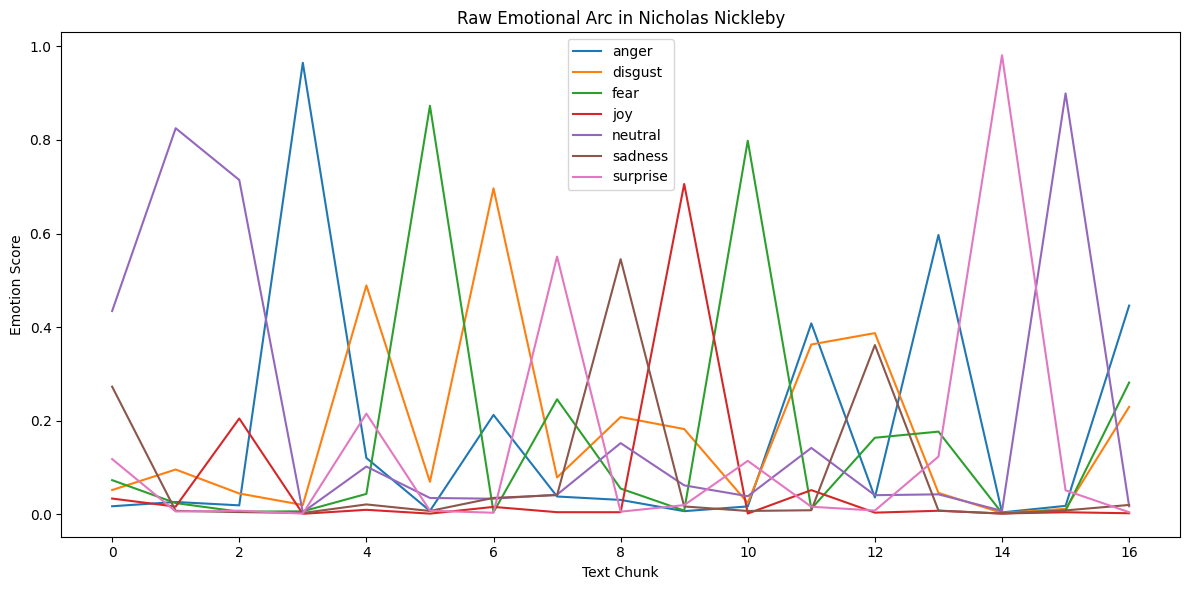

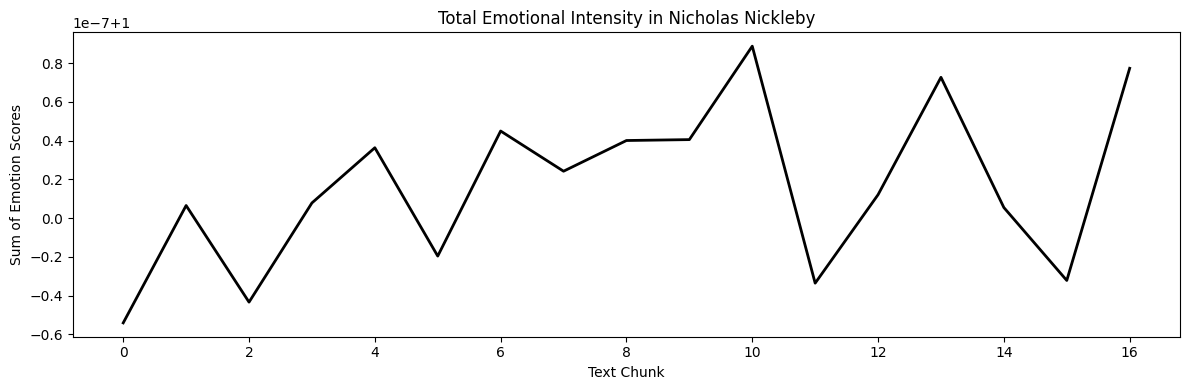

In [12]:
# Analyze emotions in each chunk WITHOUT normalization
emotion_scores = []
for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        score_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(score_dict)
    except Exception as e:
        print(f"Error: {e}")
        continue

# Convert to DataFrame
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Plot individual emotions
plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)
plt.legend()
plt.title("Raw Emotional Arc in Nicholas Nickleby")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.tight_layout()
plt.show()

# ➕ Now sum all raw emotions at each chunk
df["Total_Emotion"] = df.sum(axis=1)

# Plot total emotional intensity
plt.figure(figsize=(12, 4))
plt.plot(df["Total_Emotion"], color="black", linewidth=2)
plt.title("Total Emotional Intensity in Nicholas Nickleby")
plt.xlabel("Text Chunk")
plt.ylabel("Sum of Emotion Scores")
plt.tight_layout()
plt.show()

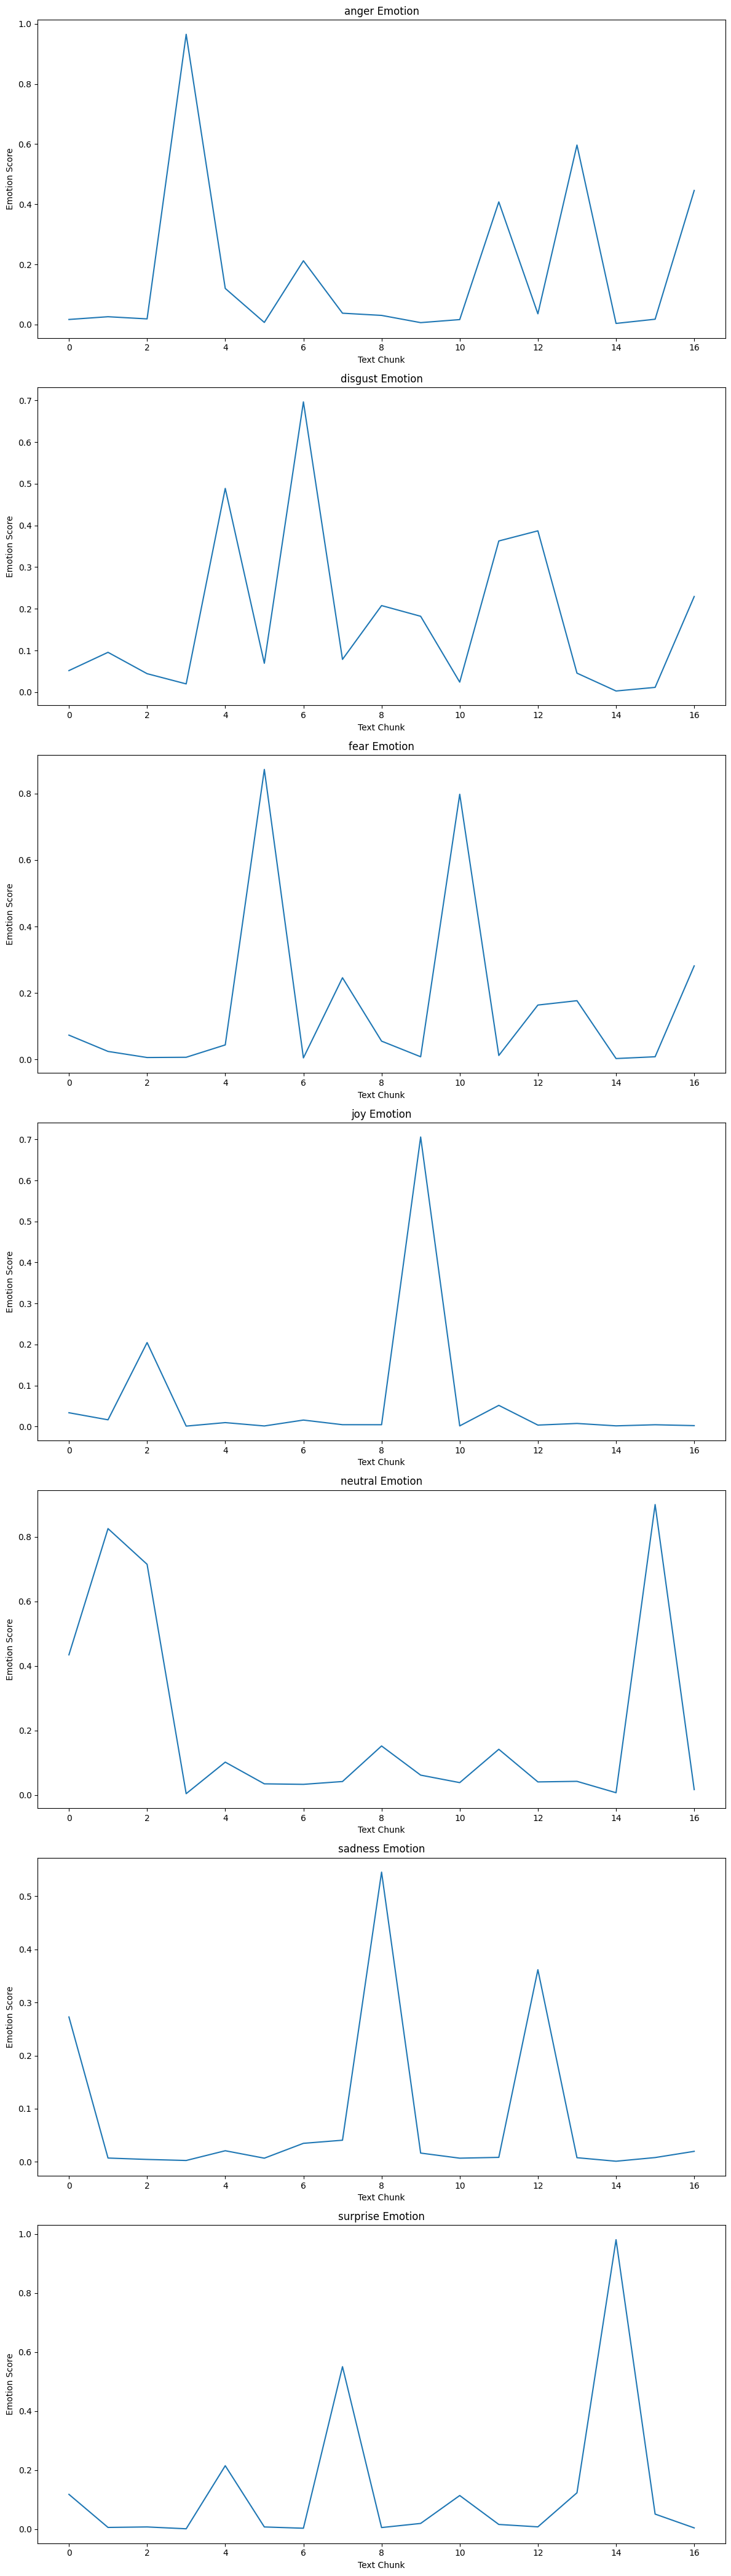

In [13]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Determine the number of emotions
num_emotions = len(df.columns)

# Set up subplots: one for each emotion
fig, axes = plt.subplots(num_emotions, 1, figsize=(12, 6 * num_emotions))

# If there's only one emotion, axes is not an array, so we handle it separately
if num_emotions == 1:
    axes = [axes]

for i, emotion in enumerate(df.columns):
    axes[i].plot(df[emotion])
    axes[i].set_title(f"{emotion} Emotion")
    axes[i].set_xlabel("Text Chunk")
    axes[i].set_ylabel("Emotion Score")

plt.tight_layout()
plt.show()